In [59]:
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold



In [30]:
train = pd.read_csv("samsung_train.txt", sep = r"\s+", header = None)
test = pd.read_csv("samsung_test.txt", sep = r"\s+", header = None)

X = pd.concat([train, test], ignore_index = True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Wymiary zbioru:", X.shape)

Wymiary zbioru: (10299, 561)


In [31]:
kmeans = KMeans(n_clusters = 6, random_state = 0, n_init = 10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print(pd.Series(kmeans_labels).value_counts().sort_index())

0    2633
1    2472
2    1926
3    1342
4    1648
5     278
Name: count, dtype: int64


In [32]:
dbscan = DBSCAN(eps = 5, min_samples = 5)
dbscan_labels = dbscan.fit_predict(X_scaled)

print(pd.Series(dbscan_labels).value_counts().sort_index())

-1    10299
Name: count, dtype: int64


In [33]:
for eps in [10, 15, 20, 25, 30]:
    dbscan = DBSCAN(eps = eps, min_samples = 5)
    dbscan_labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = list(dbscan_labels).count(-1)

    print("eps =", eps, "| klastry:", n_clusters, "| szum:", n_noise)

eps = 10 | klastry: 25 | szum: 7545
eps = 15 | klastry: 19 | szum: 2029
eps = 20 | klastry: 1 | szum: 434
eps = 25 | klastry: 2 | szum: 127
eps = 30 | klastry: 1 | szum: 47


In [34]:
for eps in [16, 17, 18, 19]:
    dbscan = DBSCAN(eps = eps, min_samples = 5)
    dbscan_labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = list(dbscan_labels).count(-1)

    print("eps =", eps, "| klastry:", n_clusters, "| szum:", n_noise)

eps = 16 | klastry: 13 | szum: 1461
eps = 17 | klastry: 5 | szum: 1034
eps = 18 | klastry: 3 | szum: 746
eps = 19 | klastry: 3 | szum: 555


In [35]:
for eps in [16.2, 16.4, 16.6, 16.8]:
    dbscan = DBSCAN(eps = eps, min_samples = 5)
    dbscan_labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = list(dbscan_labels).count(-1)

    print("eps =", eps, "| klastry:", n_clusters, "| szum:", n_noise)

eps = 16.2 | klastry: 14 | szum: 1349
eps = 16.4 | klastry: 9 | szum: 1263
eps = 16.6 | klastry: 6 | szum: 1173
eps = 16.8 | klastry: 8 | szum: 1098


In [36]:
dbscan = DBSCAN(eps = 16.6, min_samples = 5)
dbscan_labels = dbscan.fit_predict(X_scaled)

print(pd.Series(dbscan_labels).value_counts().sort_index())

-1    1173
 0    9055
 1       5
 2      14
 3       6
 4      13
 5      33
Name: count, dtype: int64


In [37]:
##DBSCAN nie daje dobrego podziału tego zbioru.

In [38]:
gmm = GaussianMixture(n_components = 6, random_state = 0)
gmm.fit(X_scaled)
gmm_labels = gmm.predict(X_scaled)

print(pd.Series(gmm_labels).value_counts().sort_index())

0    2059
1    4115
2    1496
3     770
4     112
5    1747
Name: count, dtype: int64


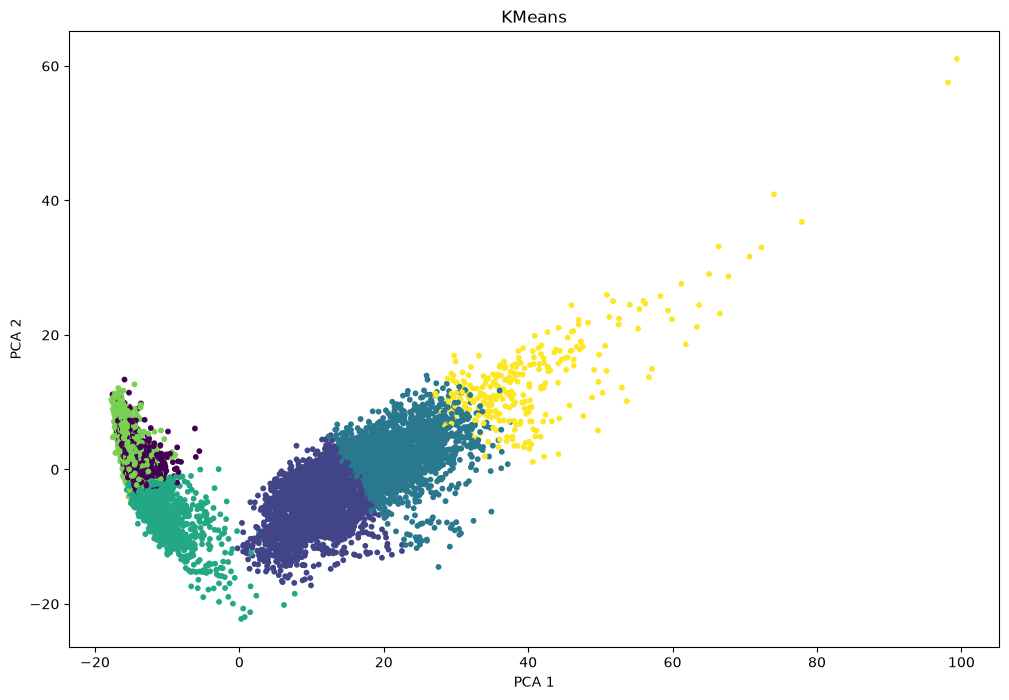

In [42]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize = (12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = kmeans_labels, s = 10)
plt.title("KMeans")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


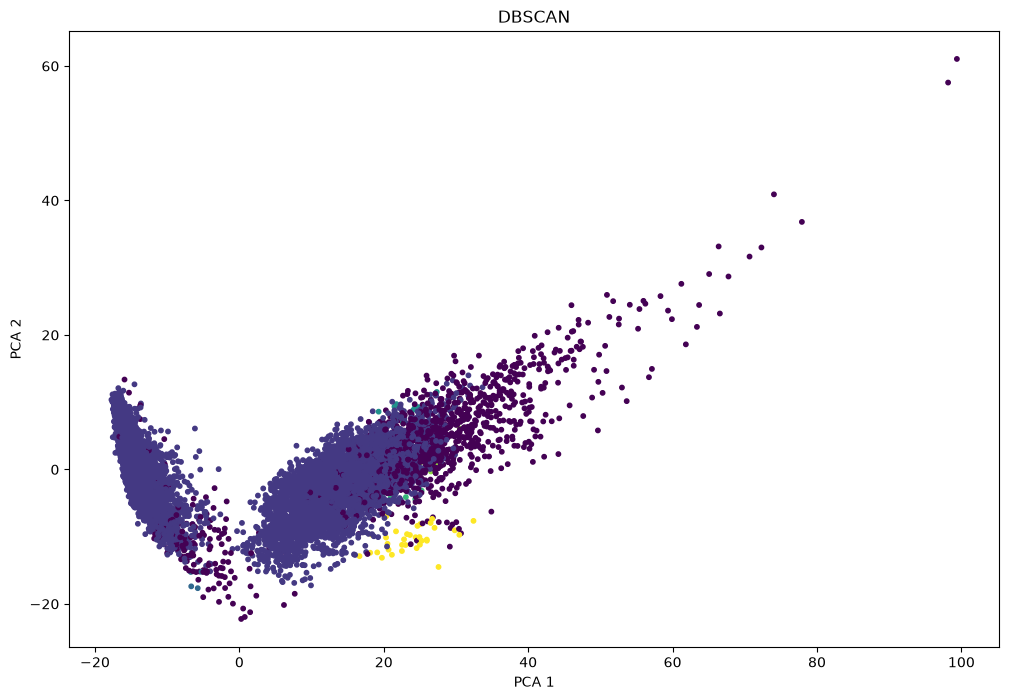

In [43]:
plt.figure(figsize = (12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = dbscan_labels, s = 10)
plt.title("DBSCAN")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

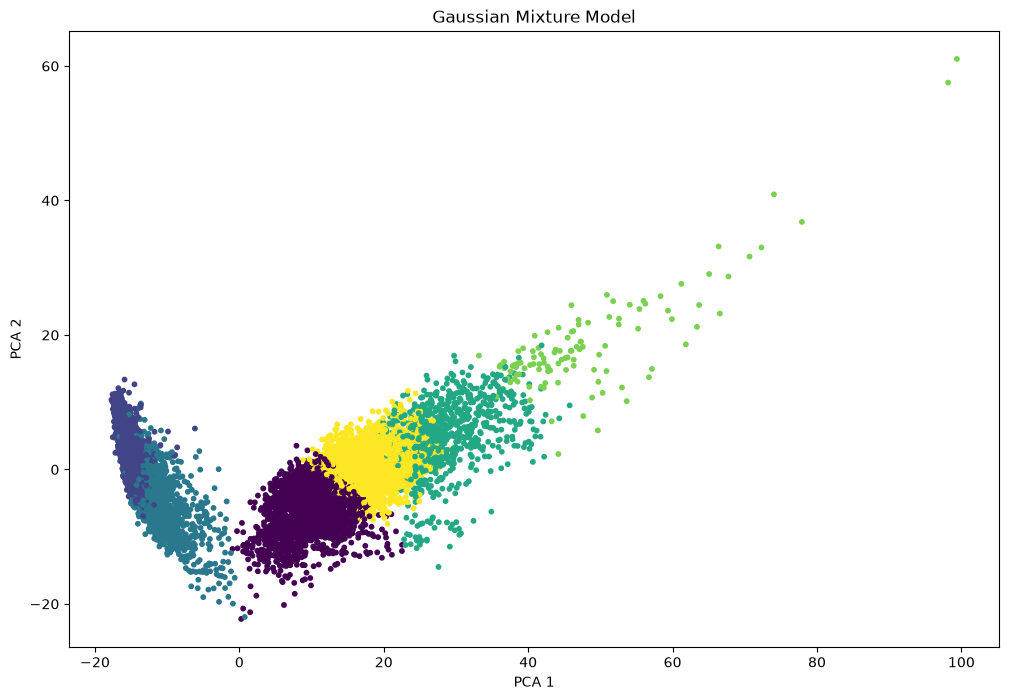

In [44]:
plt.figure(figsize = (12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = gmm_labels, s = 10)
plt.title("Gaussian Mixture Model")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [45]:
train_labels = pd.read_csv("samsung_train_labels.txt", header = None)
test_labels = pd.read_csv("samsung_test_labels.txt", header = None)

y = pd.concat([train_labels, test_labels], ignore_index = True)[0]

In [46]:
print("\nKMeans:")
print(pd.crosstab(y, kmeans_labels, rownames = ["Aktywność"], colnames = ["Klaster"]))

print("\nDBSCAN:")
print(pd.crosstab(y, dbscan_labels, rownames = ["Aktywność"], colnames = ["Klaster"]))

print("\nGaussian Mixture Model:")
print(pd.crosstab(y, gmm_labels, rownames = ["Aktywność"], colnames = ["Klaster"]))


KMeans:
Klaster       0     1    2    3     4    5
Aktywność                                 
1             0   903  742    0     0   77
2             0  1242  295    2     0    5
3             0   321  889    0     0  196
4          1237     1    0  448    91    0
5          1343     0    0  563     0    0
6            53     5    0  329  1557    0

DBSCAN:
Klaster     -1     0   1   2   3   4   5
Aktywność                               
1          177  1518   0  14   0  13   0
2          153  1352   0   0   6   0  33
3          682   724   0   0   0   0   0
4           60  1712   5   0   0   0   0
5           13  1893   0   0   0   0   0
6           88  1856   0   0   0   0   0

Gaussian Mixture Model:
Klaster       0     1    2    3   4    5
Aktywność                               
1           661     0    0  256  22  783
2          1170     0    0  110   1  263
3           212     0    0  404  89  701
4             3  1321  453    0   0    0
5             0  1310  596    0   0    

In [47]:
##KMeans wypadł najlepiej.

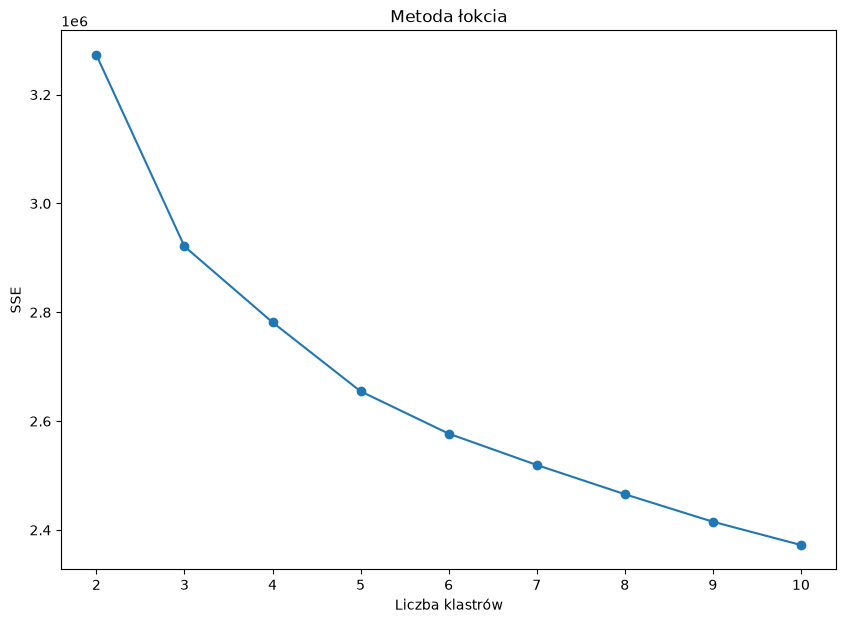

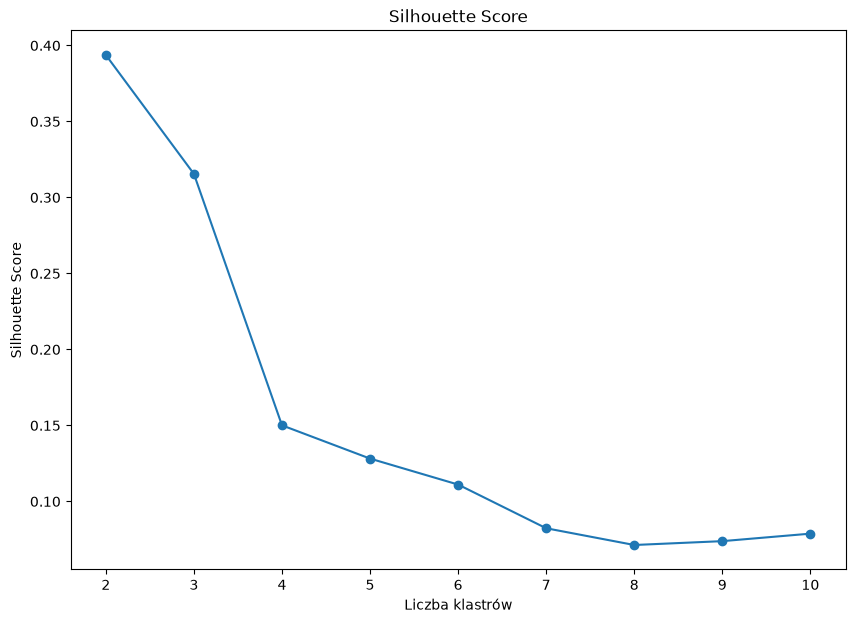

Liczba klastrów: 2 | Silhouette Score: 0.39373247640770803
Liczba klastrów: 3 | Silhouette Score: 0.3154837527273416
Liczba klastrów: 4 | Silhouette Score: 0.15006080423337922
Liczba klastrów: 5 | Silhouette Score: 0.1281749836327445
Liczba klastrów: 6 | Silhouette Score: 0.11108228309556317
Liczba klastrów: 7 | Silhouette Score: 0.08233709609003563
Liczba klastrów: 8 | Silhouette Score: 0.07132149600801871
Liczba klastrów: 9 | Silhouette Score: 0.07385580261702182
Liczba klastrów: 10 | Silhouette Score: 0.07878747409532896


In [50]:
clusters = range(2, 11)
sse = []
silhouette_scores = []

for n_clusters in clusters:
    model = KMeans(n_clusters = n_clusters, random_state = 0, n_init = 10)
    labels = model.fit_predict(X_scaled)
    sse.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize = (10, 7))
plt.plot(clusters, sse, marker = "o")
plt.xlabel("Liczba klastrów")
plt.ylabel("SSE")
plt.title("Metoda łokcia")
plt.show()

plt.figure(figsize = (10, 7))
plt.plot(clusters, silhouette_scores, marker = "o")
plt.xlabel("Liczba klastrów")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

for n_clusters, score in zip(clusters, silhouette_scores):
    print("Liczba klastrów:", n_clusters, "| Silhouette Score:", score)

In [51]:
kmeans = KMeans(n_clusters = 2, random_state = 0, n_init = 10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print(pd.Series(kmeans_labels).value_counts().sort_index())


KMeans:
0    4679
1    5620
Name: count, dtype: int64


In [52]:
print(pd.crosstab(y, kmeans_labels, rownames = ["Aktywność"], colnames = ["Klaster"]))

Klaster       0     1
Aktywność            
1          1722     0
2          1536     8
3          1406     0
4             3  1774
5             0  1906
6            12  1932


In [56]:
X_train = train.copy()
X_test = test.copy()
y_train = train_labels[0]
y_test = test_labels[0]

scaler_supervised = StandardScaler()

X_train_scaled = scaler_supervised.fit_transform(X_train)
X_test_scaled = scaler_supervised.transform(X_test)

kmeans_preprocessing = KMeans(n_clusters = 2, random_state = 0, n_init = 10)
kmeans_preprocessing.fit(X_train_scaled)

train_clusters = kmeans_preprocessing.predict(X_train_scaled)
test_clusters = kmeans_preprocessing.predict(X_test_scaled)

X_train_preprocessed = pd.DataFrame(X_train_scaled)
X_test_preprocessed = pd.DataFrame(X_test_scaled)

X_train_preprocessed.columns = X_train_preprocessed.columns.astype(str)
X_test_preprocessed.columns = X_test_preprocessed.columns.astype(str)

X_train_preprocessed["cluster"] = train_clusters
X_test_preprocessed["cluster"] = test_clusters

print(X_train_preprocessed.shape)
print(X_test_preprocessed.shape)

(7352, 562)
(2947, 562)


In [57]:
logistic_regression = LogisticRegression(max_iter = 1000, random_state = 0)
logistic_regression.fit(X_train_preprocessed, y_train)

y_pred_lr = logistic_regression.predict(X_test_preprocessed)

print("\nLogistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 macro:", f1_score(y_test, y_pred_lr, average = "macro"))


Logistic Regression:
Accuracy: 0.9552086868001357
F1 macro: 0.9549930262133719


In [58]:
random_forest = RandomForestClassifier(random_state = 0)
random_forest.fit(X_train_preprocessed, y_train)

y_pred_rf = random_forest.predict(X_test_preprocessed)

print("\nRandom Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 macro:", f1_score(y_test, y_pred_rf, average = "macro"))


Random Forest:
Accuracy: 0.9290804207668816
F1 macro: 0.9270122969828386


In [61]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 10)

params_lr = {'C': [0.007, 0.02, 0.13, 1, 44, 666]}

lr_gridsearch = GridSearchCV(logistic_regression,
                             params_lr,
                             scoring = 'f1_macro',
                             cv = 5,
                             n_jobs = -1)

lr_gridsearch.fit(X_train_preprocessed, y_train)

y_pred_lr_best = lr_gridsearch.predict(X_test_preprocessed)

print("Best hyperparameter:", lr_gridsearch.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_lr_best))
print("F1 macro:", f1_score(y_test, y_pred_lr_best, average = "macro"))

Najlepsze hiperparametry: {'C': 1}
Accuracy: 0.9552086868001357
F1 macro: 0.9549930262133719


In [62]:
random_forest = RandomForestClassifier(n_estimators = 1000, n_jobs = -1)

params_rf = {'max_depth': [3, 5, 10, 20], 'min_samples_leaf': [3, 5, 10, 15]}

rf_gridsearch = GridSearchCV(random_forest,
                             params_rf,
                             scoring = 'f1_macro',
                             cv = 5,
                             n_jobs = -1)

rf_gridsearch.fit(X_train_preprocessed, y_train)

y_pred_rf_best = rf_gridsearch.predict(X_test_preprocessed)

print("Best hyperparameter:", rf_gridsearch.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_rf_best))
print("F1 macro:", f1_score(y_test, y_pred_rf_best, average = "macro"))

Najlepsze hiperparametry: {'max_depth': 20, 'min_samples_leaf': 10}
Accuracy: 0.9209365456396336
F1 macro: 0.9183364867807274


In [ ]:
## KMeans - algorytm Unsupervised Learning, grupowanie w klastry (K - liczba klastrów)
## K-fold - metoda oceny skuteczności modelu uczenia maszynowego (K - liczba części zbioru)
## K Nearest Neighbors - algorytm Supervised Learning, zakłada że obiekty blisko siebie są podobne (K - liczba najbliższych sasiadów)